# Mean Reversion Backtest - Rolling OLS

In this notebook we backtest a cross-sectional mean reversion strategy using 4-hour crypto data from 2022 to 2024, across a universe of 70 crypto assets. We use rolling OLS to regress each asset's returns against a market proxy, isolating the idiosyncratic component (the residual) by removing the common market factor. The strategy assumes this idiosyncratic component is mean reverting over short horizons — we go long assets that are underperforming relative to the market's prediction and short those that are overperforming.

We conduct a parameter sweep over the following: market proxy (BTC vs ETH), rolling window size, rho (the partial adjustment parameter that blends current weights with the previous period's weights to reduce turnover), alpha (the EWM smoothing parameter applied to residuals before signal construction), and the rank threshold (which controls the fraction of assets assigned non-zero weights). The optimal configuration is selected by maximising net Sharpe ratio on the training period and evaluated out of sample.

Overall, we find that with ETH as the market proxy, a rolling window of 30 days, rho of 0.95, alpha (for EWM) of 0.3, and a rank threshold of 0.10, the strategy achieves a gross Sharpe ratio of 2.35, net Sharpe ratio of 1.14, alpha of 0.24 and an alpha t-statistic of 4.00 against BTC as benchmark. The positive net Sharpe ratio after 20bps transaction costs and the highly significant alpha t-statistic suggest the strategy captures genuine idiosyncratic return predictability rather than simply proxying market exposure.

However, we see the beginnings of signal degredation, and in the next notebook, we use returns from 2025 onwards (until Feb 2026) for our out-of-sample test.

In [1]:
cd -q ../../

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_opt, run_backtest
from src.backtest.helpers import sharpe, results_to_series
from src.get_data.read_data import get_rets
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

## Get Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"

In [5]:
if os.path.exists(rets_parquet_path) and os.path.exists(px_parquet_path):
    rets = pd.read_parquet(rets_parquet_path)
    px = pd.read_parquet(px_parquet_path)
else:
    rets, px = get_rets(freq='4h',start_ts = start_ts,end_ts=end_ts)
    rets.to_parquet(rets_parquet_path)
    px.to_parquet(px_parquet_path)

In [6]:
px.shape

(9115, 70)

In [7]:
px.head()

,BTCUSDT,ZRXUSDT,NMRUSDT,CAKEUSDT,JASMYUSDT,COTIUSDT,SHIBUSDT,ILVUSDT,OXTUSDT,AAVEUSDT,...,SNXUSDT,HBARUSDT,RADUSDT,RLCUSDT,ENSUSDT,YFIUSDT,RVNUSDT,BCHUSDT,AUDIOUSDT,OGNUSDT
open_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,46813.20,0.8220,31.79,11.96,0.0916,0.3575,0.000034,1019.0,0.3669,261.2,...,5.732,0.2939,10.800,2.991,39.65,33573.73,0.10299,435.2,1.613,0.6203
2022-01-01 04:00:00+00:00,47194.73,0.8293,31.67,11.88,0.0908,0.3650,0.000034,1022.0,0.3703,258.8,...,5.737,0.2972,10.831,3.000,39.47,33129.56,0.10334,435.1,1.628,0.6228
2022-01-01 08:00:00+00:00,46758.87,0.8301,31.64,11.88,0.0843,0.3686,0.000034,1019.7,0.3669,251.3,...,5.623,0.2912,10.573,2.982,38.86,33602.39,0.10187,434.6,1.617,0.6125
2022-01-01 12:00:00+00:00,47219.04,0.8377,31.89,11.93,0.0870,0.3797,0.000034,1031.3,0.3700,255.0,...,5.883,0.2956,10.619,3.027,39.26,34230.09,0.10510,441.4,1.619,0.6223
2022-01-01 16:00:00+00:00,47329.78,0.8623,32.06,12.03,0.0878,0.3854,0.000034,1036.7,0.3743,257.3,...,5.924,0.2971,10.629,3.020,40.00,37596.19,0.10697,442.8,1.642,0.6241


### Filtering data for backtest:
Using data from 2022 to 2024 inclusive

In [8]:
px = px.loc[:"20241231"]

## Running grid optimisation

We run our strategy, sweeping over the following parameter grid:

In [9]:
param_grid = {
    "mkt_ticker":      ["BTCUSDT", "ETHUSDT"],
    "window_size": [i*30*6 for i in range(1, 4)],
    "rho":         [0.9, 0.95],
    "alpha":       [0.3, 0.5, 0.7],
    "rank_thresh": [0.05, 0.1],
}

summary = run_backtest_opt(px, freq="4h", param_grid=param_grid, method="ols")

2026-03-05 14:59:47,465 INFO: Resampled to 4h


Precomputing residuals...


Sweep: 100%|██████████| 6/6 [07:14<00:00, 72.33s/it]


The following results are sorted by net sharpe ratio (in descending order):

In [10]:
summary.head(10)

,mkt_ticker,window_size,rho,alpha_ewm,rank_thresh,gross_sharpe,net_sharpe,avg_turnover,avg_ann,vol_ann,alpha,beta,alpha_tstat,hit_rate,avg_holding_days
0,ETHUSDT,180,0.95,0.3,0.10,2.350573,1.142413,0.028431,0.242131,0.103009,0.237566,0.012416,4.003287,0.549810,5.697274
1,ETHUSDT,360,0.95,0.3,0.10,2.189507,1.001026,0.027699,0.223384,0.102025,0.219508,0.010541,3.732713,0.557567,5.694033
2,BTCUSDT,360,0.95,0.3,0.05,1.911652,0.972887,0.028197,0.251360,0.131488,0.246077,0.014368,3.247422,0.556502,5.593548
3,ETHUSDT,180,0.90,0.3,0.10,2.701257,0.967708,0.058265,0.397392,0.147114,0.390462,0.018847,4.608374,0.559696,2.780000
4,ETHUSDT,180,0.95,0.3,0.05,1.905019,0.956237,0.028939,0.254376,0.133529,0.248727,0.015361,3.232806,0.544943,5.597163
5,BTCUSDT,360,0.95,0.3,0.10,2.133638,0.949862,0.027698,0.218554,0.102432,0.214314,0.011529,3.630883,0.559087,5.694148
6,ETHUSDT,360,0.95,0.5,0.05,2.118024,0.938057,0.027613,0.216991,0.102450,0.212929,0.011048,3.606282,0.568061,5.711753
7,ETHUSDT,360,0.95,0.3,0.05,1.878255,0.937381,0.028188,0.246350,0.131159,0.241446,0.013337,3.193608,0.556806,5.595147
8,BTCUSDT,180,0.95,0.3,0.10,2.126227,0.931097,0.028434,0.221459,0.104156,0.216861,0.012505,3.614103,0.543726,5.696654
9,BTCUSDT,180,0.95,0.3,0.05,1.868144,0.928359,0.028943,0.251875,0.134827,0.246053,0.015834,3.167519,0.543270,5.596449


## Results of Optimal Setup

After running our parameter sweep, we find the optimal setup to have ETH as the market proxy, a rolling window of 180 bars (~30 days), rho of 0.95, alpha of 0.3, and a rank threshold of 0.10.

In [11]:
opt_setup = run_backtest(px, freq="4h", rho=0.95, rank_thresh=0.1, alpha=0.3, mkt_tickers=["ETHUSDT"], window_sizes=[6*30], method="ols")

2026-03-05 15:07:02,074 INFO: Resampled to 4h
mkt_ticker=ETHUSDT: 100%|██████████| 1/1 [00:06<00:00,  6.43s/it]


Using the rolling OLS method to isolate idiosyncratic returns, the optimal parameter configuration yields a gross Sharpe ratio of 2.35 and net Sharpe ratio of 1.14. The strategy generates an annualised alpha of 24% with a t-statistic of 4.00, indicating the excess returns are statistically significant and unlikely to be attributable to chance. Beta is approximately zero (0.01), confirming negligible directional market exposure as expected from a dollar-neutral construction. The hit rate of 0.55 indicates the strategy is profitable on 55% of bars — modest but consistent with a mean reversion strategy where the edge comes from a slight but consistent majority of winning trades rather than large individual gains. Average annualised return is 24% with annualised volatility of 10%, giving a favourable return-to-risk profile.

The average holding period of 5.7 days reflects a deliberate design choice, that while we will show that the mean reversion signal is strongest at the 4-hour horizon, the partial adjustment parameter (rho=0.95) slows turnover, extending the effective holding period in exchange for lower transaction costs. At 20bps per trade, acting immediately on the raw signal at every bar would be uneconomical, and this smoothing is what makes the net Sharpe of 1.14 achievable.

Taken together, these statistics suggest the strategy captures genuine idiosyncratic return predictability in the in-sample period, though the time-series analysis below reveals performance is not uniform across the full sample. We first validate the mean reversion premise using the Information Coefficient before examining the time-series behaviour in detail.

### Information Coefficient (IC) Analysis

The plot below shows the Information Coefficient (IC) at horizons of 1 through 24 bars, measured as the Spearman rank correlation between the residual signal at time t and forward returns at time t+h. A negative IC indicates that assets with high residuals (relative overperformers) tend to underperform at the next bar, and vice versa, which is consistent with mean reversion.

At h=1 (4 hours), the mean IC is -0.07, indicating a meaningful negative relationship between the residual ranking and subsequent returns. By h=2 (8 hours) the IC has decayed to -0.02, losing approximately 70% of its predictive strength in a single bar. At longer horizons the IC turns positive, suggesting mean reversion gives way to momentum, i.e. assets eventually drift back in their original direction after the initial reversal.

This rapid decay has two implications for our strategy design. First, it motivates rebalancing every bar (every 4 hours) rather than less frequently, since the signal is substantially weaker by h=2. Second, it explains why aggressive smoothing via the partial adjustment parameter (rho=0.95) and EWM residual smoothing (alpha=0.3) are necessary. Without these, the turnover required to act on the h=1 signal at every bar would be prohibitive at 20bps transaction costs.

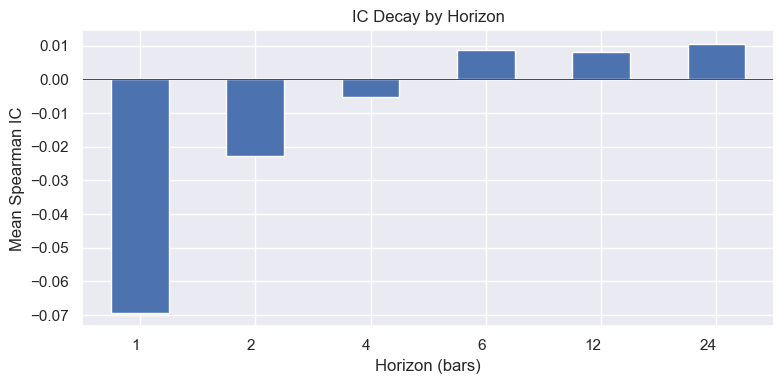

In [12]:
ic = opt_setup['ETHUSDT'][1.0]["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

Below we plot the rolling 90-day net Sharpe ratio. The strategy generated consistently strong risk-adjusted returns in the early in-sample period, with rolling Sharpe ratios frequently exceeding 2 through to the start of 2022, and this period is the primary driver of the strong full-sample Sharpe. From 2024 onwards performance deteriorates materially, with the rolling Sharpe falling to as low as -4 at points, suggesting the signal weakens significantly in the later part of the sample. This is consistent with the regime shift identified in the explained variance analysis. The increase in cross-sectional correlation from mid-2024 likely compressed the idiosyncratic return dispersion that the strategy relies on, reducing the quality of the mean reversion signal. 

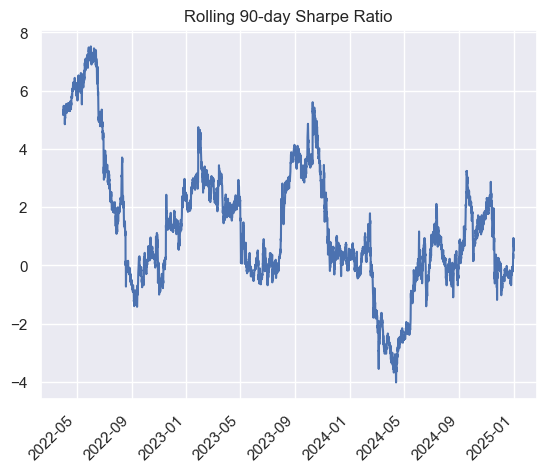

In [13]:
gross_ret = results_to_series(opt_setup, "gross_ret", col_key="ETHUSDT")[1.0]
net_ret = results_to_series(opt_setup, "net_ret", col_key="ETHUSDT")[1.0]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

We show both the gross and net cumulative returns for our strategy, presented against BTC (buy and hold) returns. This strategy is market-neutral so comparison against BTC illustrates the lack of beta exposure rather than head-to-head performance. While from mid-2024 through to the end of the year BTC outperformed our strategy, it is notable that our strategy made consistent positive returns during the 2022 bear market when BTC experienced significant drawdowns, demonstrating the value of market neutrality in such conditions.

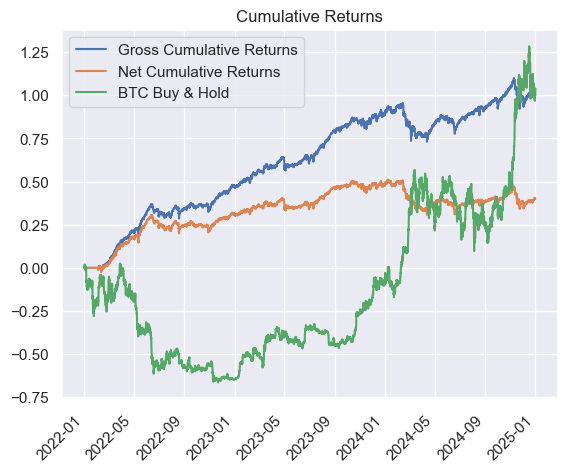

In [14]:
gross_cum = results_to_series(opt_setup, "gross_cum", col_key="ETHUSDT")
net_cum = results_to_series(opt_setup, "net_cum", col_key="ETHUSDT")

rets = rets.loc[:"20241231"]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Below we identify three notable drawdown periods in the net returns. The first occurs from July 2022 to January 2023, coinciding with the broader crypto bear market, where net drawdown reaches -0.08. A shorter, shallower drawdown follows from approximately May 2023 to August 2023, reaching -0.05. The most significant drawdown begins at the end of 2023 and persists through to the end of the in-sample period without recovery, reaching a trough of -0.125. This prolonged drawdown is consistent with the deterioration in rolling Sharpe ratio observed over the same period, and both are likely attributable to the same underlying cause; the compression of cross-sectional return dispersion as crypto market correlation increased from mid-2024 onwards, reducing the idiosyncratic signal the strategy relies on.

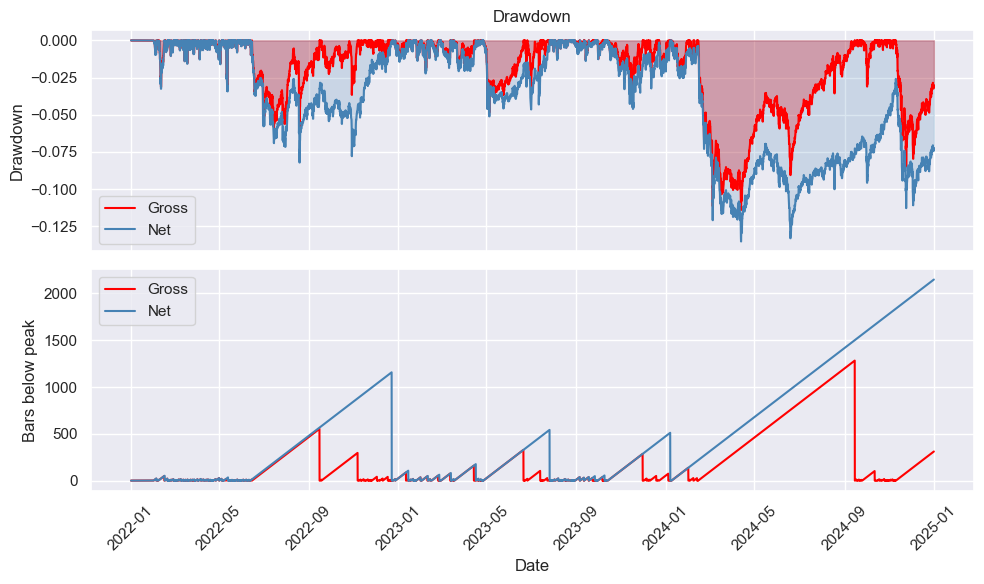

In [15]:
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

A key challenge in implementing this strategy is managing turnover sufficiently to remain profitable after transaction costs. We address this through two mechanisms: exponential weighted moving average smoothing of the residuals before signal construction, and partial adjustment of portfolio weights, which blends each period's target weights with the previous period's weights at rate rho. Together these reduce average turnover to 0.028 per bar. The plot below shows the resulting turnover over time.

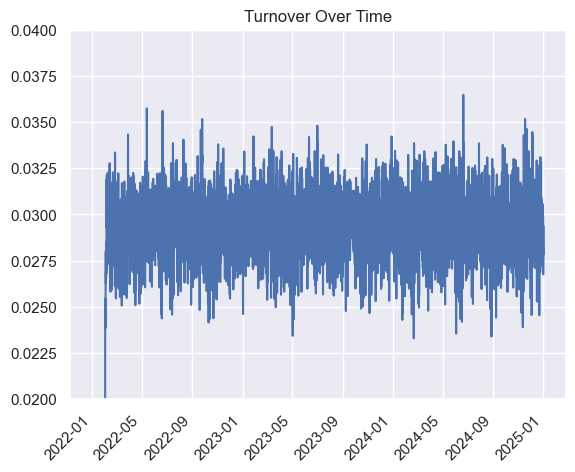

In [16]:
gross_ret = results_to_series(opt_setup, "gross_ret", col_key="ETHUSDT")[1.0]
to = results_to_series(opt_setup, "to", col_key="ETHUSDT")[1.0]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.02, 0.04)
plt.show()

In the following, we show that as transaction costs increase beyond our 20bps baseline assumption, strategy performance degrades materially. At 40bps the strategy becomes marginally unprofitable with a net Sharpe of -0.07. This suggests a relatively narrow margin of safety — the strategy requires execution quality close to 20bps to remain viable. This is a relevant concern for crypto assets that are less liquid or have wider bid-ask spreads than the large-cap names in our universe. For the most liquid assets such as BTC and ETH, 20bps is a reasonable assumption for a taker strategy, but for smaller-cap assets in our universe this figure may be optimistic, and in practice a blended cost assumption of 25-30bps across the full universe may be more realistic. The strategy's sensitivity to transaction costs therefore represents a key limitation of this approach.

In [17]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.44
 20bps: net Sharpe = 1.14
 30bps: net Sharpe = 0.54
 40bps: net Sharpe = -0.07
